In [1]:
# 1. Setup and Imports
!pip install textblob pandas nltk matplotlib
import pandas as pd
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
    --------------------------------------- 10.2/625.0 kB ? eta -:--:--
   - ------------------------------------- 20.5/625.0 kB 217.9 kB/s eta 0:00:03
   - ------------------------------------- 30.7/625.0 kB 187.9 kB/s eta 0:00:04
   - ------------------------------------- 30.7/625.0 kB 187.9 kB/s eta 0:00:04
   --- ----------------------------------- 61.4/625.0 kB 233.8 kB/s eta 0:00:03
   ---- ---------------------------------- 71.7/625.0 kB 245.8 kB/s eta 0:00:03
   ------ ------------------------------- 102.4/625.0 kB 295.4 kB/s eta 0:00:02
   -------- ----------------------------- 143.4/625.0 kB 370.8 kB/s eta 0:00:02
   ----------- -------------------------- 184.3/625.0 kB 412.5 kB/s eta 0:00:02
   ------------- ------------------------ 225.3/625.0 kB 474.7 kB/s eta 0:00:01
   --------------- ---------------------- 256.0/625.0 kB 491.5 kB/

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [5]:
# 2. Load and Preprocess 
df = pd.read_csv('../data/complaints.csv')
df.dropna(subset=['ticket_text'], inplace=True)

def clean_text(text):
    text = text.lower()
    words = text.split()
    cleaned = [w for w in words if w not in stop_words]
    return " ".join(cleaned)

df['cleaned_text'] = df['ticket_text'].apply(clean_text)

In [6]:
# 3. Sentiment Scoring 
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0: return 'Positive'
    elif polarity < 0: return 'Negative'
    else: return 'Neutral'

df['sentiment'] = df['cleaned_text'].apply(get_sentiment)

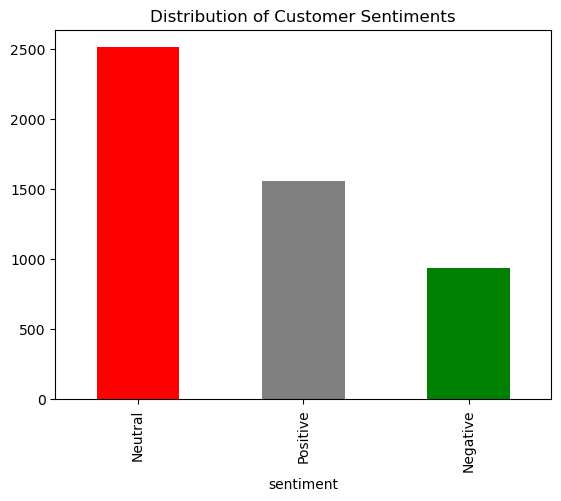

In [7]:
# 4. Visualization 
df['sentiment'].value_counts().plot(kind='bar', color=['red', 'gray', 'green'])
plt.title("Distribution of Customer Sentiments")
plt.show()